In [27]:
import torch
import pandas as pd

from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from datasets import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader

In [28]:
from datasets import load_dataset

dataset = load_dataset(
    "geraldmc/plantvillage-full",
    revision="v0.1.0"
)

data = dataset["train"]

print("Total images:", len(data))

Total images: 54304


In [29]:
train_full = data.filter(lambda x: x["split"] == "train")
test_dataset = data.filter(lambda x: x["split"] == "test")

print("Official training:", len(train_full))
print("Official test:", len(test_dataset))

Official training: 43356
Official test: 10948


In [30]:
train_df = train_full.to_pandas()
test_df = test_dataset.to_pandas()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (43356, 8)
Test : (10948, 8)


In [31]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.10,
    random_state=42
)

train_indices, val_indices = next(
    splitter.split(
        train_df,
        groups=train_df["leaf_id"]
    )
)

train_df_split = train_df.iloc[train_indices].reset_index(drop=True)
val_df_split = train_df.iloc[val_indices].reset_index(drop=True)

print("Training:", len(train_df_split))
print("Validation:", len(val_df_split))
print("Test:", len(test_df))

Training: 39106
Validation: 4250
Test: 10948


In [32]:
train_leaves = set(train_df_split["leaf_id"])
val_leaves = set(val_df_split["leaf_id"])
test_leaves = set(test_df["leaf_id"])

print(
    "Train/Validation overlap:",
    len(train_leaves & val_leaves)
)

print(
    "Train/Test overlap:",
    len(train_leaves & test_leaves)
)

print(
    "Validation/Test overlap:",
    len(val_leaves & test_leaves)
)

Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


In [33]:
from datasets import Dataset, Image as HFImage

train_dataset = Dataset.from_pandas(
    train_df_split,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df_split,
    preserve_index=False
)

# Explicitly restore the image column as a Hugging Face Image feature
train_dataset = train_dataset.cast_column(
    "image",
    HFImage()
)

val_dataset = val_dataset.cast_column(
    "image",
    HFImage()
)

print("Train dataset:", train_dataset)
print("Validation dataset:", val_dataset)

Train dataset: Dataset({
    features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
    num_rows: 39106
})
Validation dataset: Dataset({
    features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
    num_rows: 4250
})


In [34]:
test_dataset = test_dataset.cast_column(
    "image",
    HFImage()
)

print("Test dataset:", test_dataset)

Test dataset: Dataset({
    features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
    num_rows: 10948
})


In [35]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
    degrees=15,
    fill=(255, 255, 255)
),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [36]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [37]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\ASUS\Desktop\Neural Networks Models\plant-disease-cnn


In [38]:
from src.data.dataset import PlantDiseaseDataset

print("PlantDiseaseDataset imported successfully!")

PlantDiseaseDataset imported successfully!


In [39]:
train_ds = PlantDiseaseDataset(
    train_dataset,
    transform=train_transform
)

val_ds = PlantDiseaseDataset(
    val_dataset,
    transform=eval_transform
)

test_ds = PlantDiseaseDataset(
    test_dataset,
    transform=eval_transform
)

print("Train:", len(train_ds))
print("Validation:", len(val_ds))
print("Test:", len(test_ds))

Train: 39106
Validation: 4250
Test: 10948


In [40]:
sample = train_dataset[0]

print("Image type:", type(sample["image"]))
print("Image size:", sample["image"].size)
print("Image mode:", sample["image"].mode)
print("Label:", sample["class_idx"])

Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (256, 256)
Image mode: RGB
Label: 0


In [41]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [44]:
from src.data.dataset import PlantDiseaseDataset

train_ds = PlantDiseaseDataset(
    train_dataset,
    transform=train_transform
)

val_ds = PlantDiseaseDataset(
    val_dataset,
    transform=eval_transform
)

test_ds = PlantDiseaseDataset(
    test_dataset,
    transform=eval_transform
)

print("Train:", len(train_ds))
print("Validation:", len(val_ds))
print("Test:", len(test_ds))

Train: 39106
Validation: 4250
Test: 10948


In [45]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [46]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Labels dtype: torch.int64


In [47]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

images = images.to(device)
labels = labels.to(device)

print("Device:", device)
print("Images device:", images.device)
print("Labels device:", labels.device)

Device: cuda
Images device: cuda:0
Labels device: cuda:0


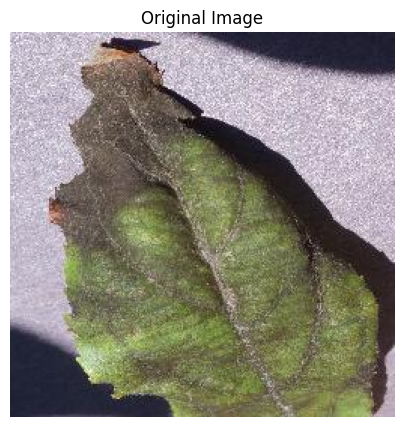

In [48]:
import matplotlib.pyplot as plt

original = train_dataset[0]["image"]

plt.figure(figsize=(5, 5))
plt.imshow(original)
plt.axis("off")
plt.title("Original Image")
plt.show()

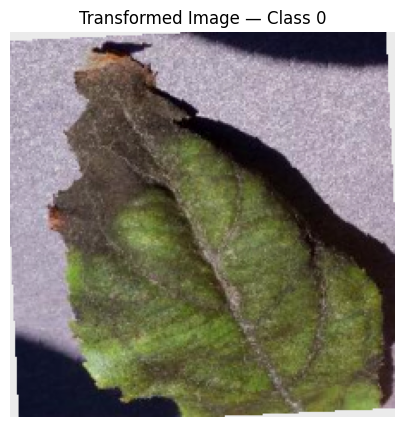

In [49]:
transformed, label = train_ds[0]

# Undo ImageNet normalization for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

display_image = transformed * std + mean
display_image = display_image.clamp(0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(display_image.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Transformed Image — Class {label.item()}")
plt.show()

In [50]:
print("TRAINING SET")
print("=" * 60)

train_counts = train_df_split["class_label"].value_counts().sort_index()
print(train_counts)

print("\nVALIDATION SET")
print("=" * 60)

val_counts = val_df_split["class_label"].value_counts().sort_index()
print(val_counts)

print("\nTEST SET")
print("=" * 60)

test_counts = test_df["class_label"].value_counts().sort_index()
print(test_counts)

TRAINING SET
class_label
Apple___Apple_scab                                     454
Apple___Black_rot                                      444
Apple___Cedar_apple_rust                               212
Apple___healthy                                       1232
Blueberry___healthy                                   1134
Cherry_(including_sour)___Powdery_mildew               692
Cherry_(including_sour)___healthy                      601
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     373
Corn_(maize)___Common_rust_                            871
Corn_(maize)___Northern_Leaf_Blight                    710
Corn_(maize)___healthy                                 837
Grape___Black_rot                                      840
Grape___Esca_(Black_Measles)                          1004
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)             788
Grape___healthy                                        303
Orange___Haunglongbing_(Citrus_greening)              3894
Peach___Bacterial_spot         

In [51]:
print("Smallest training class:")
print(train_counts.nsmallest(5))

print("\nLargest training class:")
print(train_counts.nlargest(5))

Smallest training class:
class_label
Potato___healthy                112
Apple___Cedar_apple_rust        212
Peach___healthy                 247
Tomato___Tomato_mosaic_virus    276
Raspberry___healthy             282
Name: count, dtype: int64

Largest training class:
class_label
Orange___Haunglongbing_(Citrus_greening)    3894
Tomato___Tomato_Yellow_Leaf_Curl_Virus      3847
Soybean___healthy                           3731
Peach___Bacterial_spot                      1608
Tomato___Bacterial_spot                     1583
Name: count, dtype: int64
